In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
def load_hrv_files(file_paths):
    if isinstance(file_paths, str):
        file_paths = [file_paths]

    dataframes = []

    for file_path in file_paths:
        df = pd.read_csv(file_path)
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        dataframes.append(df)

    combined_df = pd.concat(dataframes, ignore_index=True)
    combined_df = combined_df.sort_values("timestamp")

    return combined_df



In [3]:
def plot_hrv(df):
    """
    Plot HRV metrics over time.
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # RMSSD
    axes[0].plot(df["timestamp"], df["rmssd"], label="RMSSD")
    axes[0].set_ylabel("RMSSD")
    axes[0].set_title("Heart Rate Variability (HRV) Over Time")
    axes[0].legend()

    # LF & HF
    axes[1].plot(df["timestamp"], df["low_frequency"], label="Low Frequency (LF)")
    axes[1].plot(df["timestamp"], df["high_frequency"], label="High Frequency (HF)")
    axes[1].set_ylabel("Power")
    axes[1].legend()

    # LF/HF Ratio
    axes[2].plot(df["timestamp"], df["LF/HF"], label="LF/HF Ratio")
    axes[2].set_ylabel("LF/HF")
    axes[2].set_xlabel("Time")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


In [4]:

data = load_hrv_files([r"c:\TEMP\Heart Rate Variability Details - 2026-03-01.csv",
                     r"c:\TEMP\Heart Rate Variability Details - 2026-03-02.csv",
                     r"c:\TEMP\Heart Rate Variability Details - 2026-03-03.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-04.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-05.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-06.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-07.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-08.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-09.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-10.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-11.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-12.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-13.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-14.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-15.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-16.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-17.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-18.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-19.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-20.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-21.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-22.csv",
                       r"c:\TEMP\Heart Rate Variability Details - 2026-03-23.csv",
                      ])

print("Returned object:", data)
print("Type:", type(data))
print("Rows:", len(data))


Returned object:                timestamp   rmssd  coverage  low_frequency  high_frequency
0    2026-03-01 00:00:00  17.945     1.002        676.836          82.410
1    2026-03-01 00:05:00  18.513     1.003       1475.347          92.253
2    2026-03-01 00:10:00  15.279     1.001        284.640          74.209
3    2026-03-01 00:15:00  14.859     1.003         87.385          84.224
4    2026-03-01 00:20:00  18.850     0.859        400.622          82.396
...                  ...     ...       ...            ...             ...
2161 2026-03-23 23:35:00  32.598     1.002        206.231         306.414
2162 2026-03-23 23:40:00  29.599     1.004        159.822         260.374
2163 2026-03-23 23:45:00  29.228     0.833        807.929         203.573
2164 2026-03-23 23:50:00  25.718     1.003        636.903         200.266
2165 2026-03-23 23:55:00  22.958     0.993        305.281         156.949

[2166 rows x 5 columns]
Type: <class 'pandas.DataFrame'>
Rows: 2166


In [5]:

# Ensure timestamp index
if not isinstance(data.index, pd.DatetimeIndex):
    data["timestamp"] = pd.to_datetime(data["timestamp"])
    data = data.set_index("timestamp")



daily_stats = data.resample("D").agg(["mean", "std"])


rmssd_mean = daily_stats["rmssd"]["mean"]
rmssd_std  = daily_stats["rmssd"]["std"]


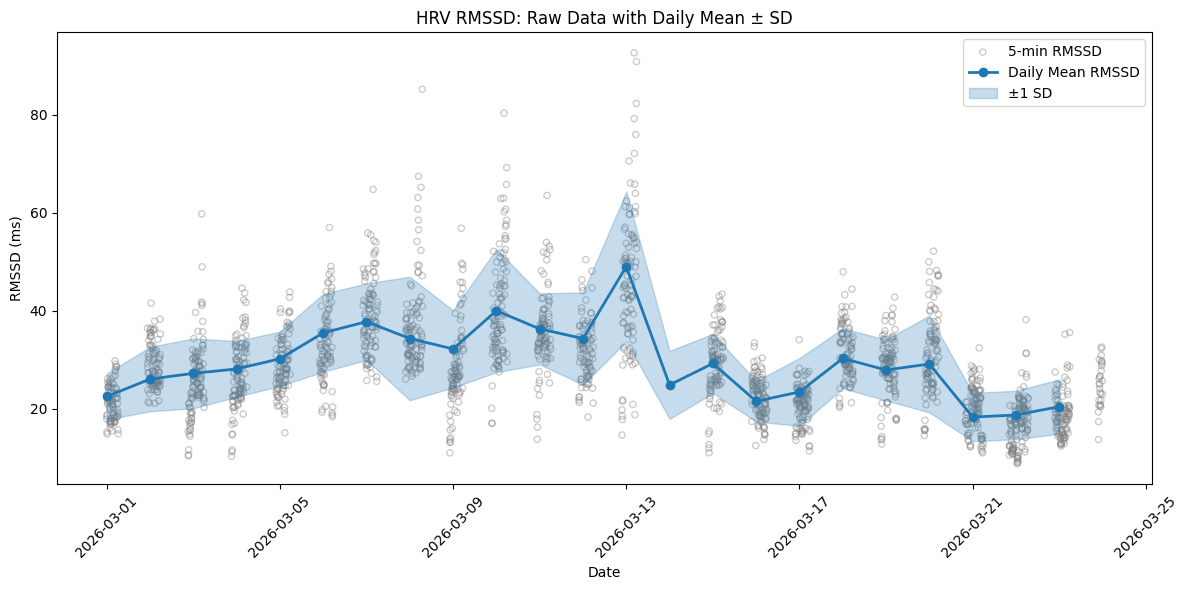

In [6]:


plt.figure(figsize=(12, 6))

# -------------------------------------------------
# Raw 5‑minute RMSSD data as OPEN CIRCLES
# -------------------------------------------------
plt.scatter(
    data.index,
    data["rmssd"],
    facecolors="none",      # open circles
    edgecolors="gray",
    s=20,
    alpha=0.4,
    label="5‑min RMSSD"
)

# -------------------------------------------------
# Daily mean RMSSD (line + markers)
# -------------------------------------------------
plt.plot(
    rmssd_mean.index,
    rmssd_mean,
    marker="o",
    linewidth=2,
    color="C0",
    label="Daily Mean RMSSD"
)

# -------------------------------------------------
# ±1 Standard Deviation band
# -------------------------------------------------
plt.fill_between(
    rmssd_mean.index,
    rmssd_mean - rmssd_std,
    rmssd_mean + rmssd_std,
    alpha=0.25,
    color="C0",
    label="±1 SD"
)

plt.xlabel("Date")
plt.ylabel("RMSSD (ms)")
plt.title("HRV RMSSD: Raw Data with Daily Mean ± SD")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
